In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import ttest_rel
import re
import os
from matplotlib.lines import Line2D
import glob

In [ ]:
full_data = [["data/vols_hw113.csv", "data/vols_jf522.csv", "data/vols_jt424.csv", "data/vols_nb018.csv", "data/vols_rh260.csv", "data/vols_sr773.csv", "data/vols_es189.csv"], 
[0.6814678, 0.5071688, 0.49784, 0.5286974, 0.6013217, 0.5587772, 0.5771198], 
[0.6343885, 0.5197383, 0.3806655, 0.5028403, 0.6013217, 0.5318747, 0.52038]]
#nx is index 1, mct is index 2

In [5]:
def plot_79vs120_single(file_70_90, file_120, nx_cerebellum_suv):
    df_79 = pd.read_csv(file_70_90)
    df_12 = pd.read_csv(file_120)

    label_col   = "Label Name"
    nx_mean_col = "Image mean (resliced nx_tau_pet)"
    nx_std_col  = "Image stdev (resliced nx_tau_pet)"
    nx_mean_79 =  "Image mean (resliced nx_tau_70_90)"
    nx_std_79 = "Image stdev (resliced nx_tau_70_90)"

    # Normalize
    df_12["nx_mean_norm"] = df_12[nx_mean_col] / float(nx_cerebellum_suv)
    df_12["nx_std_norm"]  = df_12[nx_std_col] / float(nx_cerebellum_suv)
    df_79["nx_mean_79"] = df_79[nx_mean_79] / float(nx_cerebellum_suv)
    df_79["nx_std_79"]  = df_79[nx_std_79] / float(nx_cerebellum_suv)

    labels = df_12[label_col].astype(str).tolist()

    # Plot (one figure only)
    plt.figure(figsize=(12, 6))
    plt.errorbar(labels, df_12["nx_mean_norm"],  yerr=df_12["nx_std_norm"],  fmt='-o', label='NX 90_120 (normalized)',  capsize=3)
    plt.errorbar(labels, df_79["nx_mean_79"], yerr=df_79["nx_std_79"], fmt='-o', label='NX 70_90 (normalized)', capsize=3)

    plt.title(f"NX Tau PET 90_120 vs 70_90 (Normalized to 90_120)")
    plt.xlabel("Label")
    plt.ylabel("Normalized Image Mean (± Std)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(range(0, 8))  # 0..7
    plt.ylim(0, 7)           # cutoff at 7
    plt.legend()
    plt.tight_layout()
    plt.show()

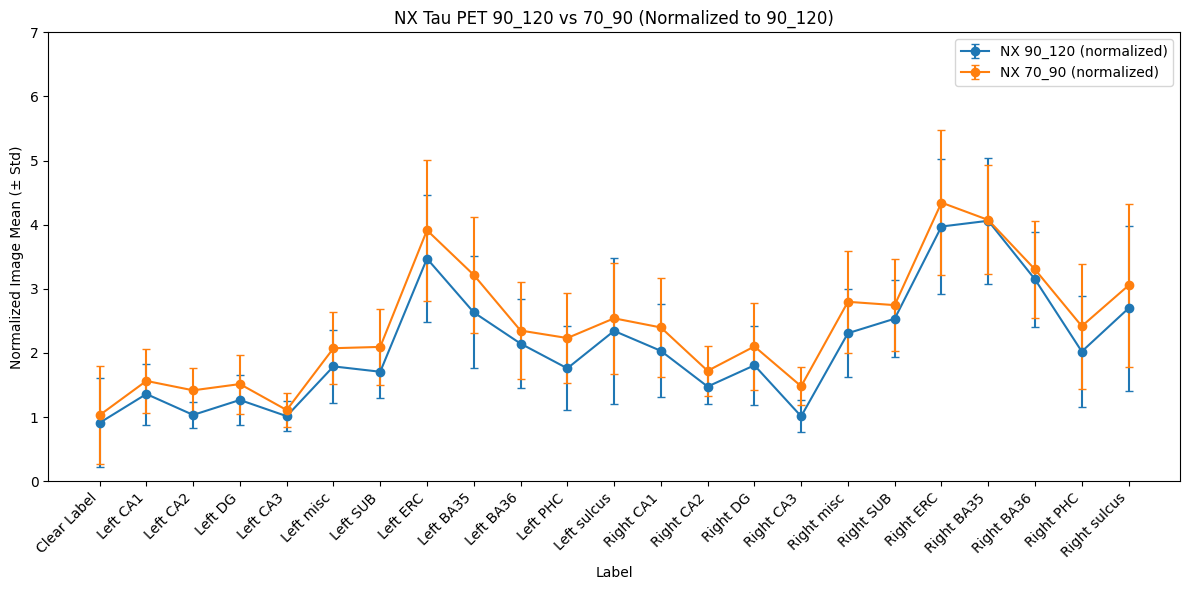

In [7]:
plot_79vs120_single("data/vols_jf522_70_90.csv", "data/vols_jf522.csv", 0.5071688)

In [3]:
def plot_tau_pet_means_single(file_path, nx_cerebellum_suv, mct_cerebellum_suv):
    """
    Plot a single figure: NX and MCT image mean (normalized by cerebellum SUV)
    with std error bars per label, y-axis fixed to 0..7.
    """
    df = pd.read_csv(file_path)

    label_col   = "Label Name"
    nx_mean_col = "Image mean (resliced nx_tau_pet)"
    nx_std_col  = "Image stdev (resliced nx_tau_pet)"
    mct_mean_col = "Image mean (resliced mct_tau_pet)"
    mct_std_col  = "Image stdev (resliced mct_tau_pet)"
    nx_70_90 =  "Image mean (resliced nx_tau_70_90)"

    # Basic validation
    for c in [label_col, nx_mean_col, nx_std_col, mct_mean_col, mct_std_col]:
        if c not in df.columns:
            raise ValueError(f"Column '{c}' not found in file: {file_path}")

    # Normalize
    df["nx_mean_norm"] = df[nx_mean_col] / float(nx_cerebellum_suv)
    df["nx_std_norm"]  = df[nx_std_col] / float(nx_cerebellum_suv)
    df["mct_mean_norm"] = df[mct_mean_col] / float(mct_cerebellum_suv)
    df["mct_std_norm"]  = df[mct_std_col] / float(mct_cerebellum_suv)

    labels = df[label_col].astype(str).tolist()

    # Plot (one figure only)
    plt.figure(figsize=(12, 6))
    plt.errorbar(labels, df["nx_mean_norm"],  yerr=df["nx_std_norm"],  fmt='-o', label='NX (normalized)',  capsize=3)
    plt.errorbar(labels, df["mct_mean_norm"], yerr=df["mct_std_norm"], fmt='-o', label='MCT (normalized)', capsize=3)

    plt.title(f"NX vs MCT Tau PET (Normalized) — {Path(file_path).name}")
    plt.xlabel("Label")
    plt.ylabel("Normalized Image Mean (± Std)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(range(0, 8))  # 0..7
    plt.ylim(0, 7)           # cutoff at 7
    plt.legend()
    plt.tight_layout()
    plt.show()

In [4]:
plot_tau_pet_means_single("data/vols_nb018_70_90.csv", 0.5286974, 0.5028403)

ValueError: Column 'Image mean (resliced nx_tau_pet)' not found in file: data/vols_nb018_70_90.csv

In [5]:
def plot_tau_pet_means_batch(df_lists, save_dir=None):
    paths, nx_suvs, mct_suvs = df_lists
    if not (len(paths) == len(nx_suvs) == len(mct_suvs)):
        raise ValueError("All three lists must have the same length.")

    for i, (p, nx_suv, mct_suv) in enumerate(zip(paths, nx_suvs, mct_suvs), start=1):
        plot_tau_pet_means_single(p, nx_suv, mct_suv)

        if save_dir is not None:
            # Re-plot quickly for a saved version (matplotlib has already shown it)
            plt.figure(figsize=(12, 6))
            df = pd.read_csv(p)

            label_col   = "Label Name"
            nx_mean_col = "Image mean (resliced nx_tau_pet)"
            nx_std_col  = "Image stdev (resliced nx_tau_pet)"
            mct_mean_col = "Image mean (resliced mct_tau_pet)"
            mct_std_col  = "Image stdev (resliced mct_tau_pet)"

            df["nx_mean_norm"] = df[nx_mean_col] / float(nx_suv)
            df["nx_std_norm"]  = df[nx_std_col] / float(nx_suv)
            df["mct_mean_norm"] = df[mct_mean_col] / float(mct_suv)
            df["mct_std_norm"]  = df[mct_std_col] / float(mct_suv)

            labels = df[label_col].astype(str).tolist()
            plt.errorbar(labels, df["nx_mean_norm"],  yerr=df["nx_std_norm"],  fmt='-o', label='NX (normalized)',  capsize=3)
            plt.errorbar(labels, df["mct_mean_norm"], yerr=df["mct_std_norm"], fmt='-o', label='MCT (normalized)', capsize=3)

            plt.title(f"NX vs MCT Tau PET (Normalized) — {Path(p).name}")
            plt.xlabel("Label")
            plt.ylabel("Normalized Image Mean (± Std)")
            plt.xticks(rotation=45, ha="right")
            plt.yticks(range(0, 8))
            plt.ylim(0, 7)
            plt.legend()
            plt.tight_layout()

            outdir = Path(save_dir)
            outdir.mkdir(parents=True, exist_ok=True)
            outfile = outdir / f"{Path(p).stem}_nx_mct_norm_0to7.png"
            plt.savefig(outfile, dpi=200)
            plt.close()

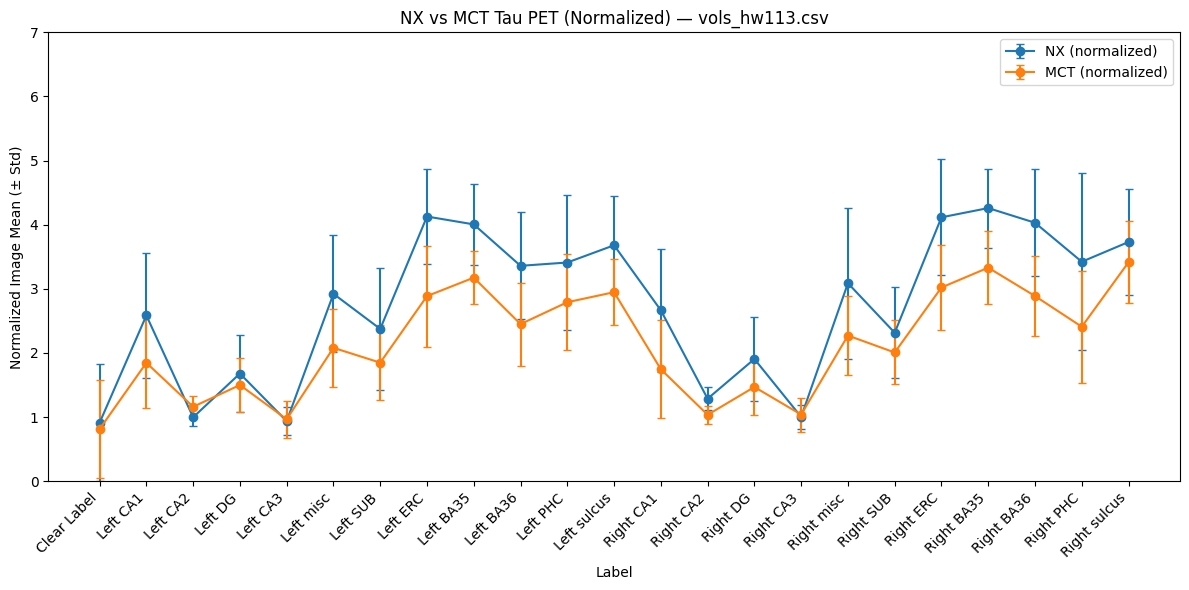

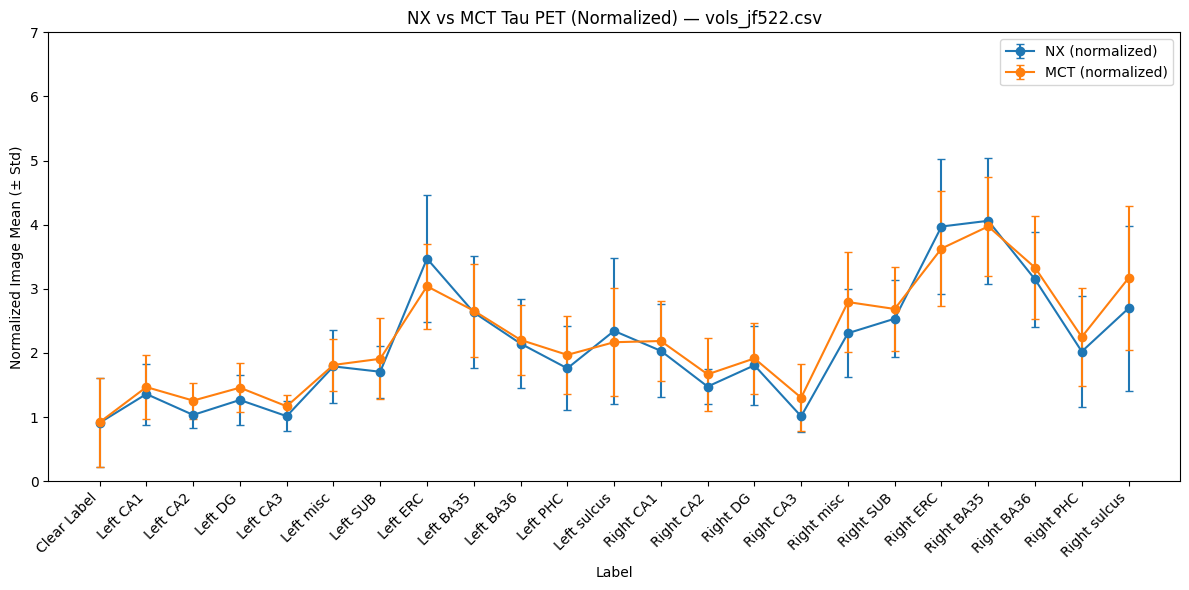

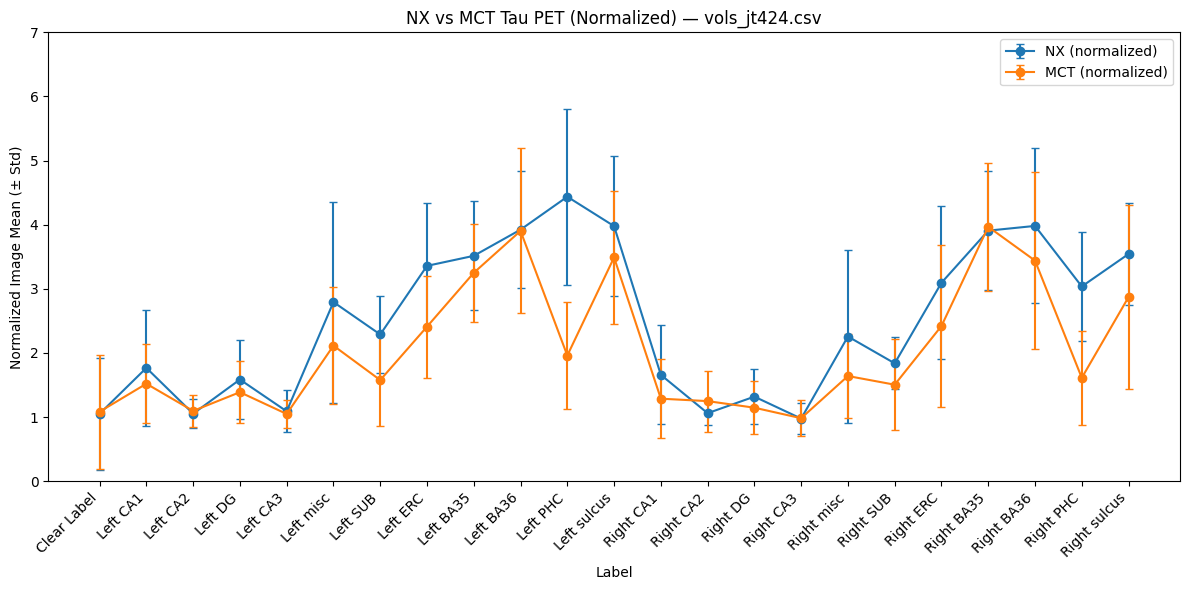

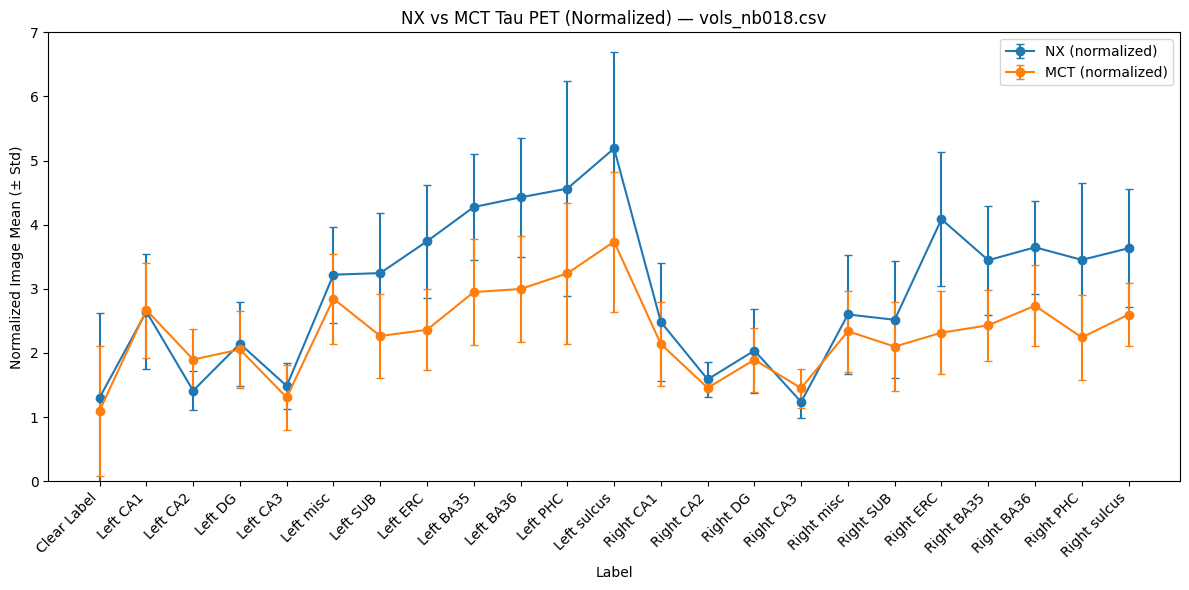

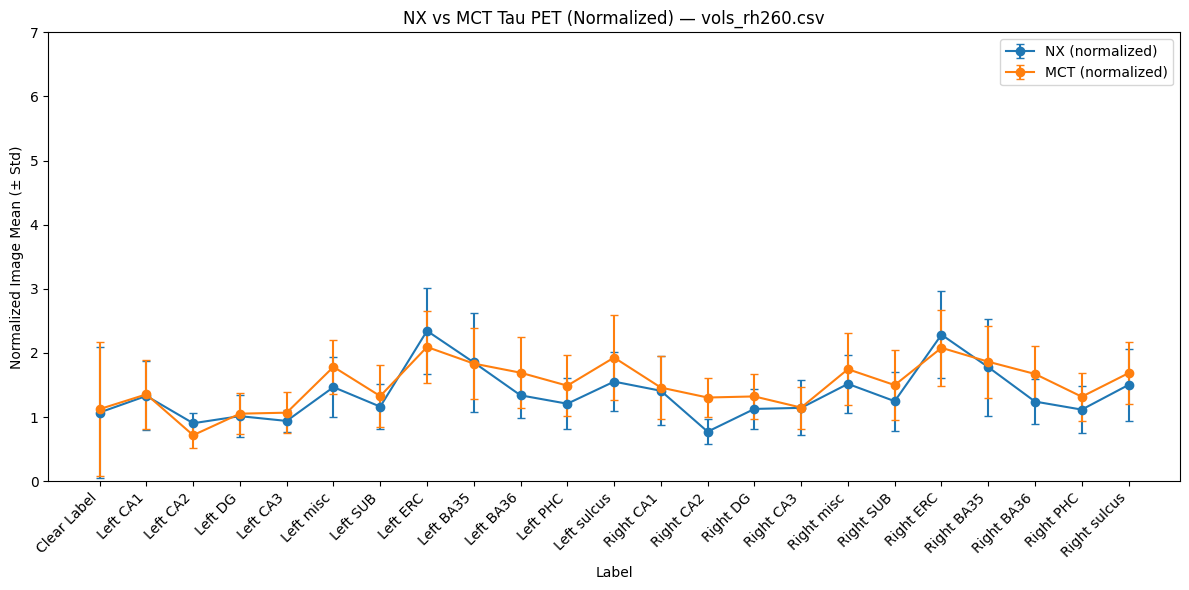

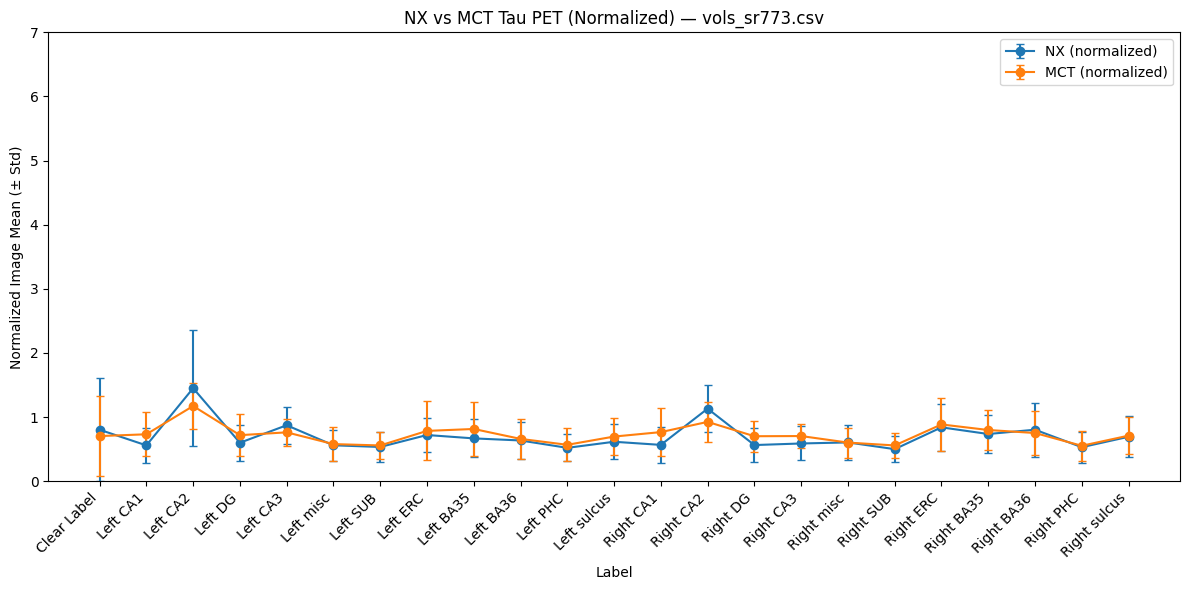

In [22]:
plot_tau_pet_means_batch(full_data)

In [7]:
def plot_group_avg_tau_pet(df_lists):
    paths, nx_suvs, mct_suvs = df_lists
    if not (len(paths) == len(nx_suvs) == len(mct_suvs)):
        raise ValueError("All three lists must have the same length.")
    
    # Compute average cerebellum SUV across 6 subjects
    nx_suv_avg  = sum(nx_suvs) / len(nx_suvs)
    mct_suv_avg = sum(mct_suvs) / len(mct_suvs)

    # Storage for all subjects’ normalized data
    dfs = []

    for i, path in enumerate(paths):
        df = pd.read_csv(path)
        # Required columns
        label_col   = "Label Name"
        nx_mean_col = "Image mean (resliced nx_tau_pet)"
        nx_std_col  = "Image stdev (resliced nx_tau_pet)"
        mct_mean_col = "Image mean (resliced mct_tau_pet)"
        mct_std_col  = "Image stdev (resliced mct_tau_pet)"

        for c in [label_col, nx_mean_col, nx_std_col, mct_mean_col, mct_std_col]:
            if c not in df.columns:
                raise ValueError(f"Column '{c}' not found in file: {path}")

        # Normalize by average cerebellum SUV (not subject-specific)
        df = df[[label_col, nx_mean_col, nx_std_col, mct_mean_col, mct_std_col]].copy()
        df["nx_mean_norm"]  = df[nx_mean_col] / nx_suv_avg
        df["nx_std_norm"]   = df[nx_std_col]  / nx_suv_avg
        df["mct_mean_norm"] = df[mct_mean_col] / mct_suv_avg
        df["mct_std_norm"]  = df[mct_std_col]  / mct_suv_avg
        df["subject"] = Path(path).stem
        dfs.append(df)
    
    # Combine all six
    combined = pd.concat(dfs, ignore_index=True)

    # Group by label: compute mean and std across subjects
    summary = (
        combined.groupby("Label Name")
        .agg(
            nx_mean_avg=("nx_mean_norm", "mean"),
            nx_mean_std=("nx_mean_norm", "std"),
            mct_mean_avg=("mct_mean_norm", "mean"),
            mct_mean_std=("mct_mean_norm", "std")
        )
        .reset_index()
    )

    # Sort labels for plotting
    labels = summary["Label Name"].astype(str).tolist()

    # Plot
    plt.figure(figsize=(12, 6))
    plt.errorbar(labels, summary["nx_mean_avg"], 
                 yerr=summary["nx_mean_std"], fmt='-o', 
                 label='NX (avg normalized)', capsize=3)
    plt.errorbar(labels, summary["mct_mean_avg"], 
                 yerr=summary["mct_mean_std"], fmt='-o', 
                 label='MCT (avg normalized)', capsize=3)

    plt.title("Group-Averaged NX vs MCT Tau PET (Normalized by Mean Cerebellum SUV)")
    plt.xlabel("Label")
    plt.ylabel("Normalized Image Mean (± Std)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(range(0, 8))
    plt.ylim(0, 7)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return summary  # also returns the dataframe for inspection or export

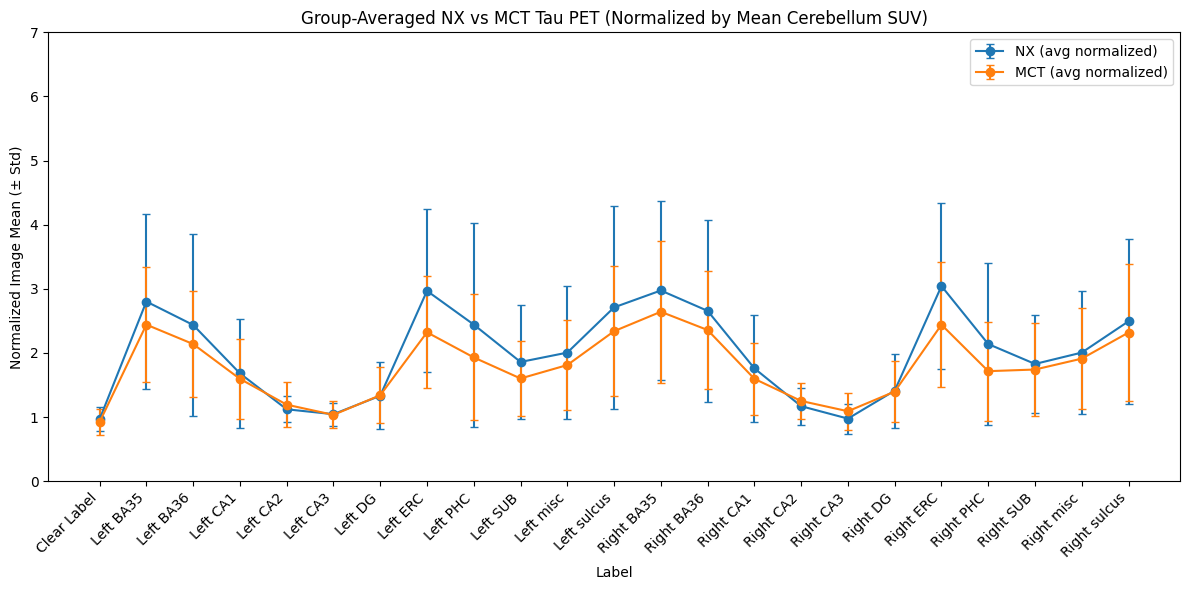

,Label Name,nx_mean_avg,nx_mean_std,mct_mean_avg,mct_mean_std
0,Clear Label,0.966563,0.185926,0.923417,0.201273
1,Left BA35,2.801884,1.362403,2.441929,0.898299
2,Left BA36,2.437093,1.424003,2.139273,0.832424
3,Left CA1,1.682154,0.850106,1.596673,0.619451
4,Left CA2,1.122058,0.203192,1.194034,0.349019
5,Left CA3,1.045616,0.176485,1.035136,0.210390
6,Left DG,1.333176,0.524534,1.341320,0.433675
7,Left ERC,2.968435,1.269604,2.322321,0.871363
8,Left PHC,2.442743,1.589478,1.930696,0.982451
9,Left SUB,1.859939,0.884759,1.602499,0.591186


In [8]:
plot_group_avg_tau_pet(full_data)

In [9]:
all_data = []

for file in full_data[0]:
    subj = file.split('_')[1].split('.')[0]
    in_df = pd.read_csv(file)

    in_df = in_df[[
        "Label Name",
        "Image mean (resliced nx_tau_pet)",
        "Image mean (resliced mct_tau_pet)"
    ]].copy()

    in_df.columns = ["ROI", "NX", "MCT"]
    in_df["subject"] = subj
    all_data.append(in_df)

data = pd.concat(all_data, ignore_index=True)

In [10]:
roi_stats = []

for roi, sub_df in data.groupby("ROI"):
        t, p = ttest_rel(sub_df["NX"], sub_df["MCT"])
        mean_diff = (sub_df["NX"] - sub_df["MCT"]).mean()
        roi_stats.append({
            "ROI": roi,
            "n_subjects": len(sub_df),
            "t_stat": round(t, 4),
            "p_val": round(p, 6),
            "mean_diff": round(mean_diff, 6)
        })

In [11]:
roi_results = pd.DataFrame(roi_stats)
roi_results.to_csv("data/roi_paired_ttest_results.csv", index=False)

In [6]:
roi_results

,ROI,n_subjects,t_stat,p_val,mean_diff
0,Clear Label,6,2.1995,0.079146,0.062920
1,Left BA35,6,1.9772,0.104948,0.318199
2,Left BA36,6,1.6339,0.163216,0.295036
3,Left CA1,6,1.2039,0.282515,0.130314
4,Left CA2,6,0.0315,0.976098,0.002008
5,Left CA3,6,0.8397,0.439375,0.034922
6,Left DG,6,1.0194,0.354783,0.061381
7,Left ERC,6,2.7899,0.038447,0.474030
8,Left PHC,6,1.5769,0.175653,0.414505
9,Left SUB,6,1.6478,0.160304,0.222939


In [47]:
ROI_COL = "Label Name"
NX_COL  = "Image mean (resliced nx_tau_pet)"
MCT_COL = "Image mean (resliced mct_tau_pet)"

DROP_CEREBELLUM_FROM_PLOT = False
CEREBELLUM_MATCH = "cerebell"  # case-insensitive substring

In [7]:
records = []
paths, nx_cereb_list, mct_cereb_list = full_data

for path, nx_cer, mct_cer in zip(paths, mct_cereb_list, nx_cereb_list):
    subj = path.split("/")[-1].split("_", 1)[-1].split(".")[0]  # e.g., vols_hw113.csv -> hw113
    df = pd.read_csv(path)

    # normalize means by provided cerebellum SUVs (condition-specific)
    tmp = df[[ROI_COL, MCT_COL, NX_COL]].copy()
    tmp["subject"] = subj
    tmp["mct_norm"] = tmp[MCT_COL].astype(float) / float(mct_cer)
    tmp["nx_norm"]  = tmp[NX_COL].astype(float)  / float(nx_cer)

    if DROP_CEREBELLUM_FROM_PLOT:
        mask = tmp[ROI_COL].astype(str).str.contains(CEREBELLUM_MATCH, case=False, na=False)
        tmp = tmp.loc[~mask]

    records.append(tmp[[ROI_COL, "subject", "mct_norm", "nx_norm"]])

data = pd.concat(records, ignore_index=True)

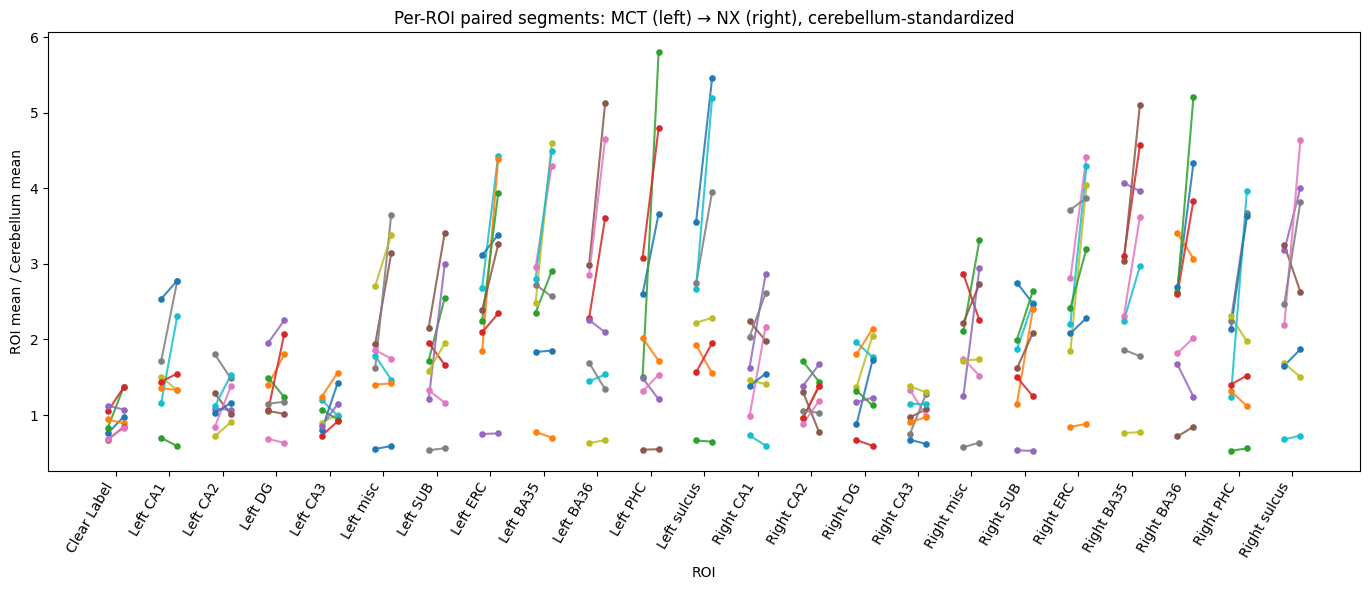

In [14]:
roi_order = data[ROI_COL].drop_duplicates().tolist()
x_positions = {roi: i for i, roi in enumerate(roi_order)}
left_offset, right_offset = -0.15, 0.15

plt.figure(figsize=(max(8, 0.6 * len(roi_order)), 6))

for roi in roi_order:
    subdf = data[data[ROI_COL] == roi]
    x = x_positions[roi]
    for _, r in subdf.iterrows():
        # short, unconnected segment per subject at this ROI
        plt.plot([x + left_offset, x + right_offset],
                 [r["mct_norm"], r["nx_norm"]],
                 linewidth=1.5, alpha=0.85)
        plt.scatter([x + left_offset, x + right_offset],
                    [r["mct_norm"], r["nx_norm"]],
                    s=14, zorder=3)

plt.xticks(list(x_positions.values()), roi_order, rotation=60, ha="right")
plt.xlabel("ROI")
plt.ylabel("ROI mean / Cerebellum mean")
plt.title("Per-ROI paired segments: MCT (left) → NX (right), cerebellum-standardized")
plt.tight_layout()
plt.show()

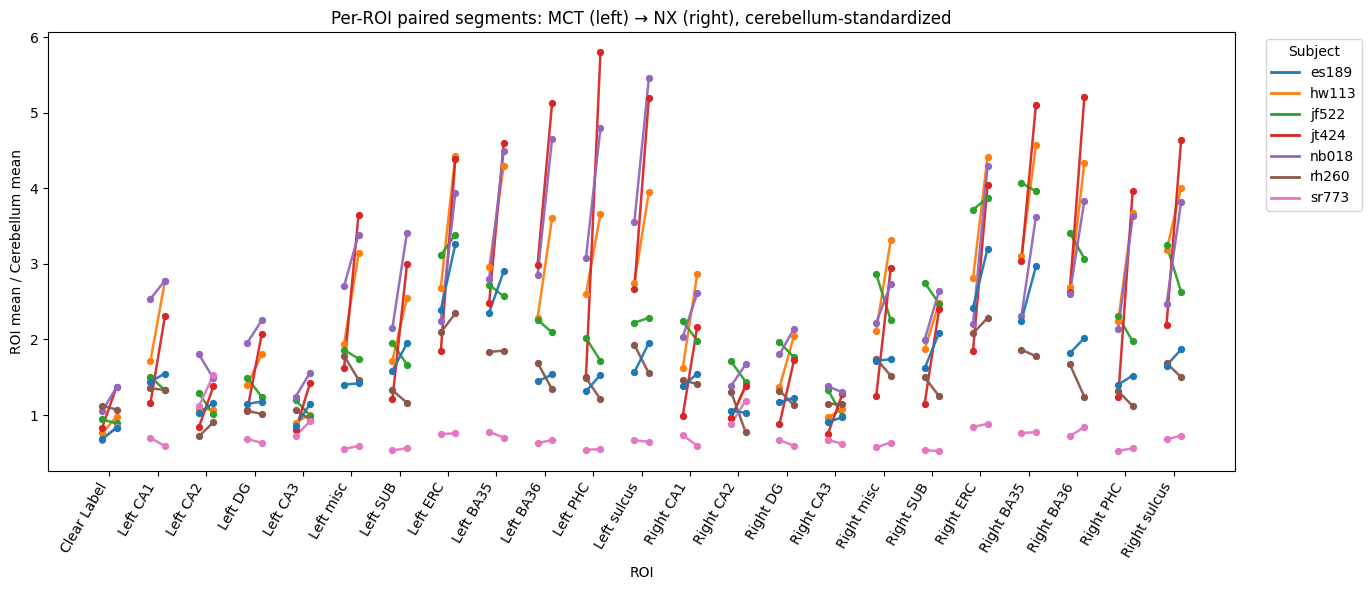

In [15]:
# consistent color per subject
subjects = sorted(data["subject"].unique())
cmap = plt.get_cmap("tab10")
subj_color = {s: cmap(i % 10) for i, s in enumerate(subjects)}

roi_order = data[ROI_COL].drop_duplicates().tolist()
x_positions = {roi: i for i, roi in enumerate(roi_order)}
left_offset, right_offset = -0.15, 0.15

plt.figure(figsize=(max(8, 0.6 * len(roi_order)), 6))

for roi in roi_order:
    subdf = data[data[ROI_COL] == roi]
    x = x_positions[roi]
    for _, r in subdf.iterrows():
        col = subj_color[r["subject"]]
        # short, unconnected segment per subject at this ROI
        plt.plot([x + left_offset, x + right_offset],
                 [r["mct_norm"], r["nx_norm"]],
                 linewidth=1.8, alpha=0.95, color=col)
        plt.scatter([x + left_offset, x + right_offset],
                    [r["mct_norm"], r["nx_norm"]],
                    s=18, zorder=3, color=col)

plt.xticks(list(x_positions.values()), roi_order, rotation=60, ha="right")
plt.xlabel("ROI")
plt.ylabel("ROI mean / Cerebellum mean")
plt.title("Per-ROI paired segments: MCT (left) → NX (right), cerebellum-standardized")

# legend
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=subj_color[s], lw=2, label=s) for s in subjects]
plt.legend(handles=handles, title="Subject", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [18]:
data

,Label Name,subject,MCT,NX,Number Of Voxels,side,base_roi
0,Clear Label,hw113,0.813727,0.911725,5987797,None,Clear Label
1,Left CA1,hw113,1.847307,2.585522,2711,Left,CA1
2,Left CA2,hw113,1.161478,0.997112,98,Left,CA2
3,Left DG,hw113,1.500465,1.679522,1992,Left,DG
4,Left CA3,hw113,0.966909,0.937239,111,Left,CA3
...,...,...,...,...,...,...,...
133,Right ERC,sr773,0.885733,0.840464,1563,Right,ERC
134,Right BA35,sr773,0.799094,0.736619,1834,Right,BA35
135,Right BA36,sr773,0.752125,0.803782,5203,Right,BA36
136,Right PHC,sr773,0.553243,0.530847,3345,Right,PHC


In [44]:
CSV_PATHS = full_data[0]
MCT_CEREB = full_data[1]
NX_CEREB  = full_data[2]

ROI_COL = "Label Name"
NX_COL  = "Image mean (resliced nx_tau_pet)"
MCT_COL = "Image mean (resliced mct_tau_pet)"

# optional base dir, depending on where files are stored
BASE_DIR = ""   # change to "" if running locally
def resolve_path(p):
    cand = os.path.join(BASE_DIR, os.path.basename(p))
    return cand if os.path.exists(cand) else p

In [17]:
# ---------------------------
# 2. Load + normalize by cerebellum SUV
# ---------------------------
records = []
for path, mct_c, nx_c in zip(CSV_PATHS, MCT_CEREB, NX_CEREB):
    csv_path = resolve_path(path)
    subj = os.path.basename(csv_path).split("_", 1)[-1].split(".")[0]
    df = pd.read_csv(csv_path)

    for col in (ROI_COL, NX_COL, MCT_COL):
        if col not in df.columns:
            raise KeyError(f"{csv_path} missing column: {col}")

    # Normalize ROI means by cerebellum SUV for that subject
    df["subject"] = subj
    df["mct_norm"] = df[MCT_COL].astype(float) / float(mct_c)
    df["nx_norm"]  = df[NX_COL].astype(float) / float(nx_c)

    records.append(df[[ROI_COL, "subject", "mct_norm", "nx_norm"]])

data = pd.concat(records, ignore_index=True)

In [18]:
# ---------------------------
# 3. Identify sides and merge Left/Right when both exist
# ---------------------------
def get_side(name):
    m = re.match(r'^\s*(Left|Right)\s+', str(name), flags=re.I)
    return m.group(1).title() if m else None

def get_base(name):
    return re.sub(r'^\s*(Left|Right)\s+', '', str(name), flags=re.I).strip()

data["side"] = data[ROI_COL].apply(get_side)
data["base_roi"] = data[ROI_COL].apply(get_base)

# Split lateralized and midline (non-left/right) ROIs
lat = data.dropna(subset=["side"])
mid = data[data["side"].isna()].copy()

# Average Left+Right for each subject and ROI
avg_lr = (
    lat.groupby(["subject", "base_roi"])
       .agg(n_sides=("side", "nunique"),
            mct_norm=("mct_norm", "mean"),
            nx_norm=("nx_norm", "mean"))
       .reset_index()
)
# Keep both-sided ROIs (n_sides == 2)
avg_lr = avg_lr[avg_lr["n_sides"] == 2].copy()

# For midline (non-left/right) ROIs, rename for consistency
mid["base_roi"] = mid[ROI_COL]
mid["n_sides"] = 1

# Combine averaged Left/Right with single ROIs
combined = pd.concat([
    avg_lr[["subject", "base_roi", "mct_norm", "nx_norm", "n_sides"]],
    mid[["subject", "base_roi", "mct_norm", "nx_norm", "n_sides"]]
], ignore_index=True)

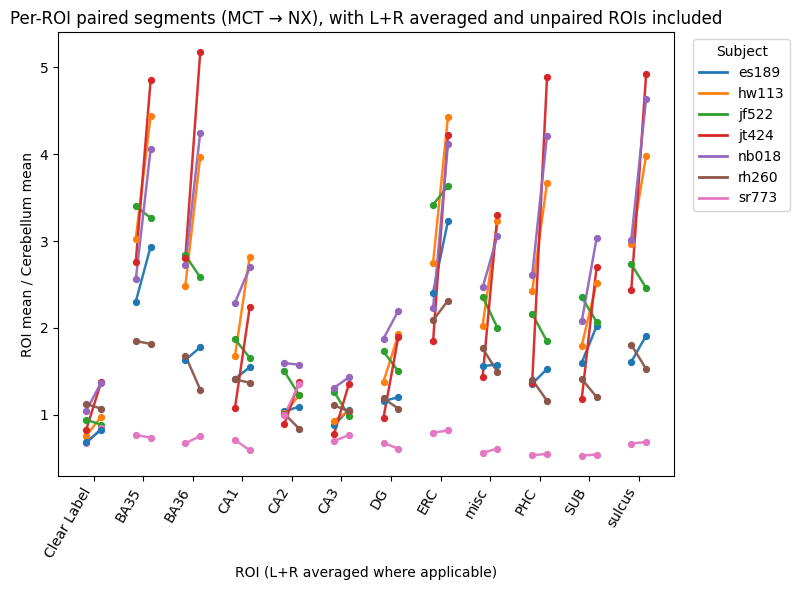

In [19]:
# ---------------------------
# 4. Plot averaged segments (include unpaired ROIs first)
# ---------------------------
subjects = sorted(combined["subject"].unique())
cmap = plt.get_cmap("tab10")
subj_color = {s: cmap(i % 10) for i, s in enumerate(subjects)}

# ROI order: unpaired first, then averaged pairs (alphabetical)
unpaired_rois = sorted(combined.loc[combined["n_sides"] == 1, "base_roi"].unique(), key=str.lower)
paired_rois   = sorted(combined.loc[combined["n_sides"] == 2, "base_roi"].unique(), key=str.lower)
roi_order = unpaired_rois + paired_rois

x_positions = {roi: i for i, roi in enumerate(roi_order)}
left_offset, right_offset = -0.15, 0.15

plt.figure(figsize=(max(8, 0.6 * len(roi_order)), 6))

for roi in roi_order:
    subdf = combined[combined["base_roi"] == roi]
    x = x_positions[roi]
    for _, r in subdf.iterrows():
        col = subj_color[r["subject"]]
        plt.plot([x + left_offset, x + right_offset],
                 [r["mct_norm"], r["nx_norm"]],
                 linewidth=1.8, alpha=0.95, color=col)
        plt.scatter([x + left_offset, x + right_offset],
                    [r["mct_norm"], r["nx_norm"]],
                    s=18, zorder=3, color=col)

plt.xticks(list(x_positions.values()), roi_order, rotation=60, ha="right")
plt.xlabel("ROI (L+R averaged where applicable)")
plt.ylabel("ROI mean / Cerebellum mean")
plt.title("Per-ROI paired segments (MCT → NX), with L+R averaged and unpaired ROIs included")

# Legend
handles = [Line2D([0], [0], color=subj_color[s], lw=2, label=s) for s in subjects]
plt.legend(handles=handles, title="Subject", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [45]:
paths, nx_cereb_list, mct_cereb_list = full_data

In [48]:
rows = []
for path, mct_cer, nx_cer in zip(paths, mct_cereb_list, nx_cereb_list):
    subj = path.split("/")[-1].split("_", 1)[-1].split(".")[0]
    df = pd.read_csv(path)

    # normalize ROI means by provided cerebellum SUVRs (condition-specific)
    tmp = df[[ROI_COL, MCT_COL, NX_COL]].copy()
    tmp["subject"]  = subj
    tmp["mct_norm"] = tmp[MCT_COL].astype(float) / float(mct_cer)
    tmp["nx_norm"]  = tmp[NX_COL].astype(float)  / float(nx_cer)

    if DROP_CEREBELLUM_FROM_PLOT:
        mask = tmp[ROI_COL].astype(str).str.contains(CEREBELLUM_MATCH, case=False, na=False)
        tmp = tmp.loc[~mask]

    # Bland–Altman variables
    tmp["mean_scanner_suvr"] = (tmp["nx_norm"] + tmp["mct_norm"]) / 2.0
    tmp["diff_nx_minus_mct"] = (tmp["nx_norm"] - tmp["mct_norm"])
    rows.append(tmp[["subject", ROI_COL, "mean_scanner_suvr", "diff_nx_minus_mct"]])

data = pd.concat(rows, ignore_index=True)

In [49]:
# ---------- Compute bias and limits of agreement ----------
bias = data["diff_nx_minus_mct"].mean()
sd   = data["diff_nx_minus_mct"].std(ddof=1)
loa_upper = bias + 1.96 * sd
loa_lower = bias - 1.96 * sd

In [50]:
rois = data[ROI_COL].unique()
for roi in rois:
    sub = data[data[ROI_COL] == roi]
    print(sub)

    subject   Label Name  mean_scanner_suvr  diff_nx_minus_mct
0     hw113  Clear Label           0.862726           0.097998
23    jf522  Clear Label           0.915163          -0.008365
46    jt424  Clear Label           1.068307          -0.032392
69    nb018  Clear Label           1.202804           0.201154
92    rh260  Clear Label           1.098188          -0.052844
115   sr773  Clear Label           0.753878           0.098876
138   es189  Clear Label           0.754082          -0.015664
    subject Label Name  mean_scanner_suvr  diff_nx_minus_mct
1     hw113   Left CA1           2.216414           0.738216
24    jf522   Left CA1           1.414252          -0.108247
47    jt424   Left CA1           1.644080           0.246691
70    nb018   Left CA1           2.657055          -0.024921
93    rh260   Left CA1           1.342749          -0.024300
116   sr773   Left CA1           0.645778          -0.173135
139   es189   Left CA1           1.498845          -0.204186
    subj

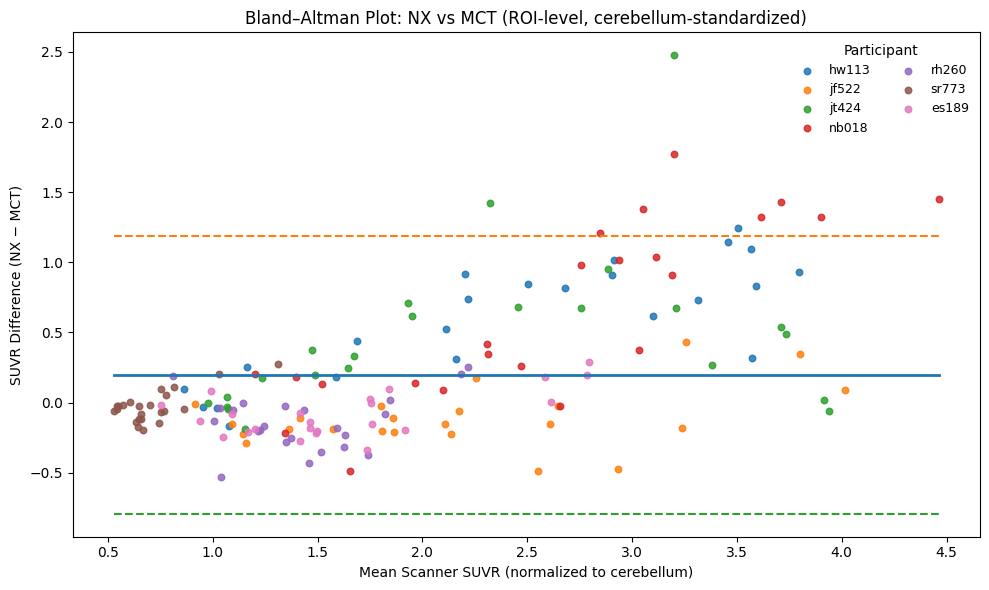

In [51]:
# ---------- Plot ----------
plt.figure(figsize=(10, 6))

# scatter (colored by PARTICIPANT)
participants = data["subject"].unique()
for subj in participants:
    sub = data[data["subject"] == subj]
    plt.scatter(
        sub["mean_scanner_suvr"],
        sub["diff_nx_minus_mct"],
        label=subj,
        s=22,
        alpha=0.85
    )
plt.legend(ncol=2, fontsize=9, frameon=False, title="Participant")
# bias & LOA lines
x_min, x_max = data["mean_scanner_suvr"].min(), data["mean_scanner_suvr"].max()
plt.plot([x_min, x_max], [bias, bias], linewidth=2)  # mean bias
plt.plot([x_min, x_max], [loa_upper, loa_upper], linestyle="--")
plt.plot([x_min, x_max], [loa_lower, loa_lower], linestyle="--")

plt.xlabel("Mean Scanner SUVR (normalized to cerebellum)")
plt.ylabel("SUVR Difference (NX − MCT)")
plt.title("Bland–Altman Plot: NX vs MCT (ROI-level, cerebellum-standardized)")
plt.tight_layout()
plt.show()

In [11]:
print(f"Mean bias (NX−MCT): {bias:.3f}")
print(f"SD of differences : {sd:.3f}")
print(f"95% LOA          : [{loa_lower:.3f}, {loa_upper:.3f}]")

Mean bias (NX−MCT): 0.241
SD of differences : 0.528
95% LOA          : [-0.793, 1.275]


In [25]:
mct_cereb = full_data[2]
nx_cereb  = full_data[1]

# Column names in your CSVs
ROI_COL  = "Label Name"
NX_COL   = "Image mean (resliced nx_tau_pet)"
MCT_COL  = "Image mean (resliced mct_tau_pet)"
NVOX_COL = "Number Of Voxels"  # optional

STANDARDIZE_BY_CEREBELLUM = True
DROP_CEREBELLUM_ROIs_FROM_PLOT = True   # hide reference regions on the plot

# -------------------- LOAD & SHAPE --------------------
rows = []

for path, mct_ref, nx_ref in zip(paths, mct_cereb_list, nx_cereb_list):
    subj = path.split("/")[-1].split("_", 1)[-1].split(".")[0]
    df = pd.read_csv(path)

    # base frame
    cols = [ROI_COL, MCT_COL, NX_COL]
    if NVOX_COL in df.columns:
        cols.append(NVOX_COL)
    tmp = df[cols].copy()
    tmp["subject"] = subj

    # condition-specific normalization (optional)
    if STANDARDIZE_BY_CEREBELLUM:
        tmp["MCT"] = tmp[MCT_COL].astype(float) / float(mct_ref)
        tmp["NX"]  = tmp[NX_COL].astype(float)  / float(nx_ref)
    else:
        tmp["MCT"] = tmp[MCT_COL].astype(float)
        tmp["NX"]  = tmp[NX_COL].astype(float)

    # drop cerebellum ROIs (typically the reference region)
    if DROP_CEREBELLUM_ROIs_FROM_PLOT:
        mask_cer = tmp[ROI_COL].astype(str).str.contains("cerebell", case=False, na=False)
        tmp = tmp.loc[~mask_cer]

    keep = [ROI_COL, "subject", "MCT", "NX"]
    if NVOX_COL in tmp.columns:
        keep.append(NVOX_COL)
    rows.append(tmp[keep])

data = pd.concat(rows, ignore_index=True)

In [26]:
# Keep only ROIs that contain "Left" or "Right" in their names
data = data[data[ROI_COL].str.contains("Left|Right", case=False, na=False)]

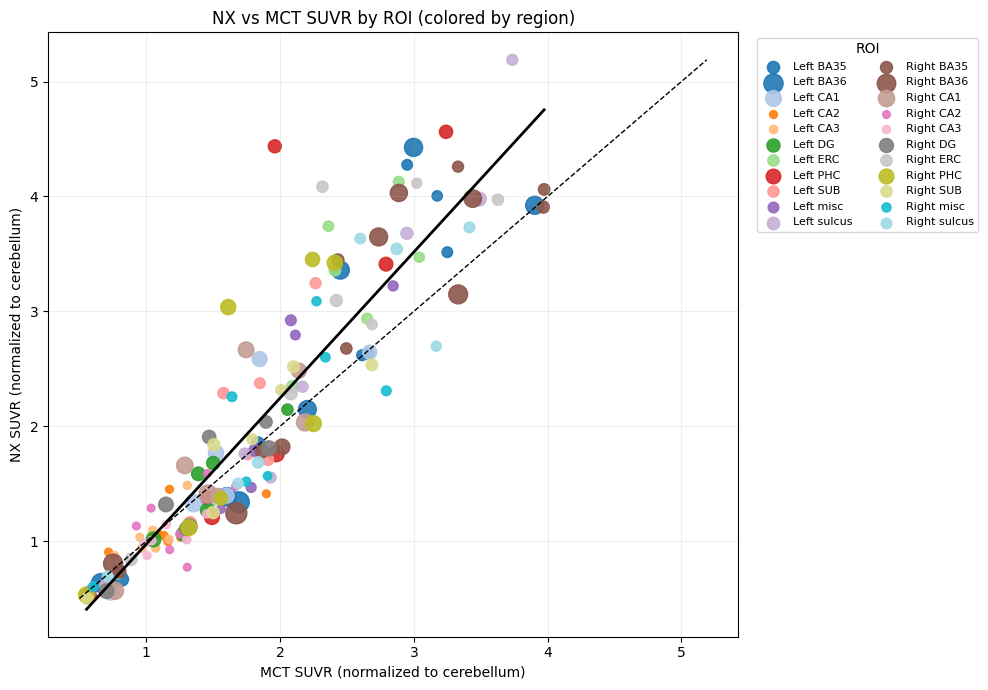

In [27]:
rois = sorted(data[ROI_COL].unique())
cmap = plt.colormaps.get("tab20")
roi_to_color = {roi: cmap(i / len(rois)) for i, roi in enumerate(rois)}

# reset row numbers so indexes go 0..N-1 again
data.reset_index(drop=True, inplace=True)

# sizes as a Series aligned to `data` (not a bare .values array)
sizes = None
if NVOX_COL in data.columns:
    s = data[NVOX_COL].astype(float)
    s = (s - s.min()) / (s.max() - s.min() + 1e-9) * 200 + 30
    sizes = s  # keep as Series

# -------------------- PLOT --------------------
plt.figure(figsize=(10, 7))

for roi in rois:
    subdf = data[data[ROI_COL] == roi]
    plt.scatter(subdf["MCT"], subdf["NX"],
                s=(sizes[subdf.index] if sizes is not None else 40),
                color=roi_to_color[roi], alpha=0.9, label=roi)

# Add reference line (perfect agreement)
xy_min = min(data["MCT"].min(), data["NX"].min())
xy_max = max(data["MCT"].max(), data["NX"].max())
plt.plot([xy_min, xy_max], [xy_min, xy_max], color="black", linestyle="--", linewidth=1)

# Add regression line
coeffs = np.polyfit(data["MCT"], data["NX"], 1)
x_line = np.linspace(data["MCT"].min(), data["MCT"].max(), 100)
plt.plot(x_line, coeffs[0]*x_line + coeffs[1], color="black", linewidth=2)

plt.xlabel("MCT SUVR (normalized to cerebellum)" if STANDARDIZE_BY_CEREBELLUM else "MCT SUVR")
plt.ylabel("NX SUVR (normalized to cerebellum)" if STANDARDIZE_BY_CEREBELLUM else "NX SUVR")
plt.title("NX vs MCT SUVR by ROI (colored by region)")
plt.grid(alpha=0.2)

# Legend / key
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=2, fontsize=8, title="ROI")

plt.tight_layout()
plt.show()

In [28]:
# -------------------- QUICK STATS --------------------
r = np.corrcoef(data["MCT"], data["NX"])[0, 1]
print(f"Pearson r = {r:.3f}")
print(f"OLS slope = {coeffs[0]:.3f}, intercept = {coeffs[1]:.3f}")

Pearson r = 0.917
OLS slope = 1.271, intercept = -0.296


In [8]:
# Custom ROI order (base names, without Left/Right)
roi_order = ["ERC", "BA35", "sulcus", "BA36", "PHC", "SUB", "CA1", "CA2", "CA3", "DG"]

In [11]:
rows = []
for path, mct_ref, nx_ref in zip(full_data[0], full_data[2], full_data[1]):
    subj = Path(path).name.split("_", 1)[-1].split(".")[0]
    df = pd.read_csv(path)

    # Keep only Left/Right, drop Clear Label
    hemi_mask = df[ROI_COL].astype(str).str.match(r"(?i)^(Left|Right)\b")
    df = df.loc[hemi_mask].copy()
    df["MCT"] = df[MCT_COL].astype(float) / float(mct_ref)
    df["NX"]  = df[NX_COL].astype(float)  / float(nx_ref)

    # Strip "Left"/"Right" prefixes
    df["base_roi"] = df[ROI_COL].str.replace(r"(?i)^(Left|Right)\s+", "", regex=True).str.strip()
    df["subject"] = subj
    rows.append(df[["subject", "base_roi", "MCT", "NX"]])

long_df = pd.concat(rows, ignore_index=True)

In [16]:
hemi_avg = long_df.groupby(["subject", "base_roi"], as_index=False)[["MCT", "NX"]].mean()

group_avg = hemi_avg.groupby("base_roi")[["MCT", "NX"]].agg(["mean", "std"])
group_avg.columns = ['_'.join(col) for col in group_avg.columns]  # MCT_mean, MCT_std, NX_mean, NX_std
group_avg.reset_index(inplace=True)

group_avg = group_avg[group_avg["base_roi"].isin(roi_order)].copy()
group_avg["base_roi"] = pd.Categorical(group_avg["base_roi"],
                                       categories=roi_order, ordered=True)
group_avg = group_avg.sort_values("base_roi")

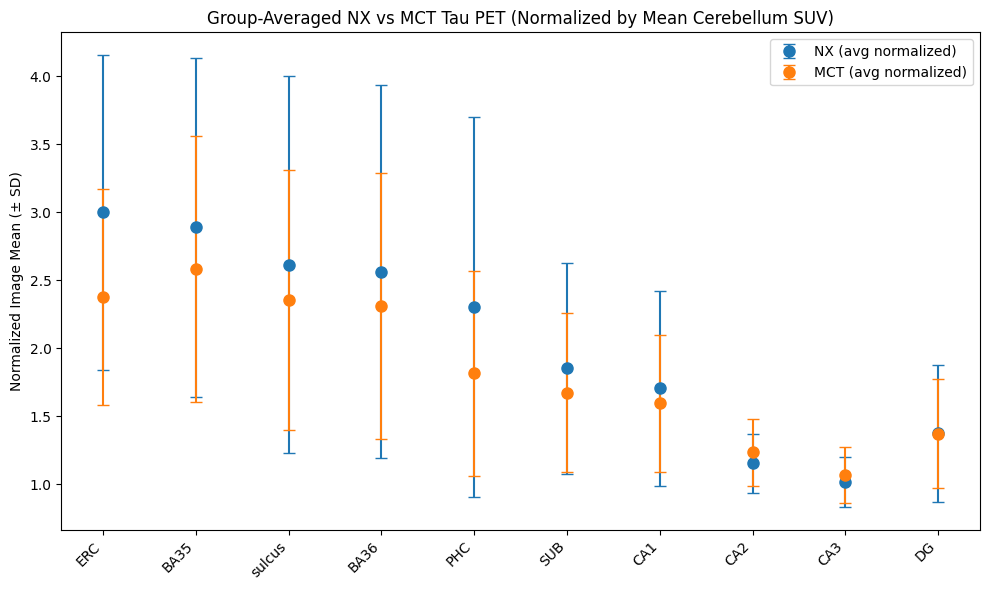

In [18]:
plt.figure(figsize=(10,6))
x = np.arange(len(group_avg))

# NX
plt.errorbar(
    x,
    group_avg["NX_mean"],
    yerr=group_avg["NX_std"],
    fmt='o',
    markersize=8,
    linestyle='none',     # <--- NO LINE
    color='#1f77b4',
    label="NX (avg normalized)",
    capsize=4
)

# MCT
plt.errorbar(
    x,
    group_avg["MCT_mean"],
    yerr=group_avg["MCT_std"],
    fmt='o',
    markersize=8,
    linestyle='none',     # <--- NO LINE
    color='#ff7f0e',
    label="MCT (avg normalized)",
    capsize=4
)

plt.xticks(x, group_avg["base_roi"], rotation=45, ha='right')
plt.ylabel("Normalized Image Mean (± SD)")
plt.title("Group-Averaged NX vs MCT Tau PET (Normalized by Mean Cerebellum SUV)")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
ROI_COL  = "Label Name"
NVOX_COL = "Number Of Voxels"

# ---------------- LOAD & PROCESS ----------------
rows = []
for path in full_data[0]:
    subj = Path(path).name.split("_", 1)[-1].split(".")[0]
    df = pd.read_csv(path)

    # Keep only Left/Right labels
    hemi_mask = df[ROI_COL].astype(str).str.match(r"(?i)^(Left|Right)\b")
    df = df.loc[hemi_mask].copy()

    # Extract base ROI name
    df["base_roi"] = df[ROI_COL].str.replace(
        r"(?i)^(Left|Right)\s+", "", regex=True
    ).str.strip()

    df["subject"] = subj
    rows.append(df[["subject", "base_roi", NVOX_COL]])

long_df = pd.concat(rows, ignore_index=True)

# -------------- AVERAGE LEFT + RIGHT PER SUBJECT --------------
hemi_avg = long_df.groupby(["subject", "base_roi"], as_index=False)[NVOX_COL].mean()

# -------------- GROUP AVERAGE ACROSS SUBJECTS --------------
vol_table = hemi_avg.groupby("base_roi")[NVOX_COL].agg(["mean", "std"])
vol_table = vol_table.rename(columns={"mean": "Volume_mean", "std": "Volume_std"})
vol_table = vol_table.reset_index()

# round for readability
vol_table["Volume_mean"] = vol_table["Volume_mean"].round(2)
vol_table["Volume_std"]  = vol_table["Volume_std"].round(2)

In [22]:
rows = []
for path, mct_ref, nx_ref in zip(full_data[0], full_data[2], full_data[1]):
    subj = Path(path).name.split("_", 1)[-1].split(".")[0]
    df = pd.read_csv(path)

    # keep only hemispheric labels (drop Clear Label, Brain Stem, etc.)
    hemi_mask = df[ROI_COL].astype(str).str.match(r"(?i)^(Left|Right)\b")
    df = df.loc[hemi_mask].copy()

    df["MCT"] = df[MCT_COL].astype(float) / float(mct_ref)
    df["NX"]  = df[NX_COL].astype(float)  / float(nx_ref)

    # strip Left/Right prefix → base ROI
    df["base_roi"] = df[ROI_COL].str.replace(
        r"(?i)^(Left|Right)\s+", "", regex=True
    ).str.strip()

    df["subject"] = subj
    rows.append(df[["subject", "base_roi", "MCT", "NX"]])

long_df = pd.concat(rows, ignore_index=True)

In [23]:
# ------------ AVERAGE L/R PER SUBJECT ------------
hemi_avg = long_df.groupby(["subject", "base_roi"], as_index=False)[["MCT","NX"]].mean()

# ------------ COMPUTE % DIFFERENCE PER SUBJECT ------------
# % diff defined as (NX - MCT)/MCT * 100
hemi_avg["pct_diff"] = (hemi_avg["NX"] - hemi_avg["MCT"]) / hemi_avg["MCT"] * 100

# ------------ GROUP ACROSS SUBJECTS ------------
group_pct = hemi_avg.groupby("base_roi")["pct_diff"].agg(["mean", "std"]).reset_index()

# restrict to your ROI order
group_pct = group_pct[group_pct["base_roi"].isin(roi_order)].copy()
group_pct["base_roi"] = pd.Categorical(group_pct["base_roi"],
                                       categories=roi_order, ordered=True)
group_pct = group_pct.sort_values("base_roi")

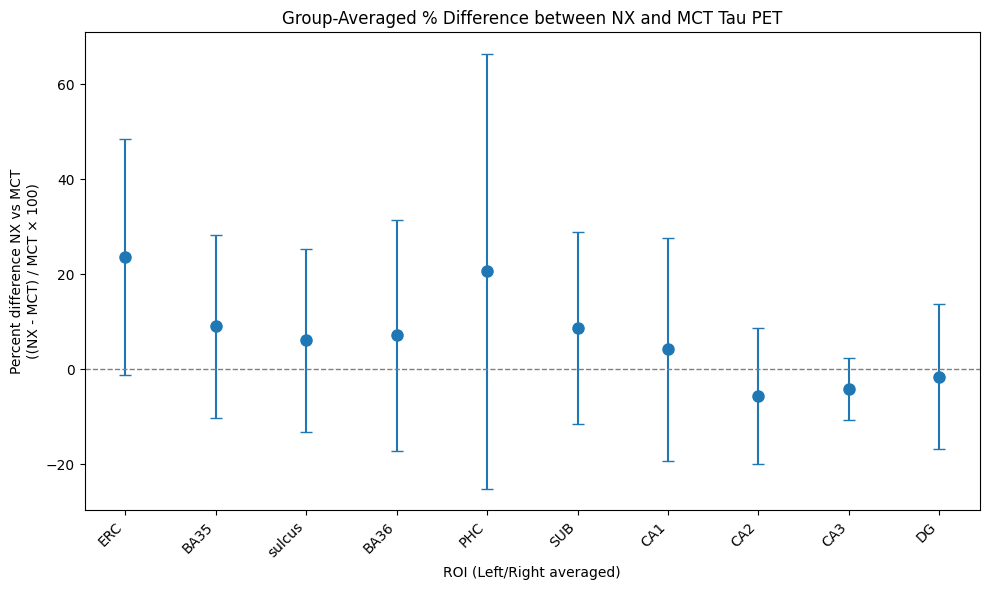

In [24]:
# ------------ PLOT ------------
plt.figure(figsize=(10, 6))
x = np.arange(len(group_pct))

plt.errorbar(
    x,
    group_pct["mean"],
    yerr=group_pct["std"],
    fmt='o',
    markersize=8,
    linestyle='none',   # no connecting lines
    color='#1f77b4',
    capsize=4,
)

# zero line for reference
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.xticks(x, group_pct["base_roi"], rotation=45, ha='right')
plt.ylabel("Percent difference NX vs MCT\n((NX - MCT) / MCT × 100)")
plt.xlabel("ROI (Left/Right averaged)")
plt.title("Group-Averaged % Difference between NX and MCT Tau PET")
plt.tight_layout()
plt.show()

#### Bland Atlman plot of 70-90 vs 90-120

In [34]:
combined_paths = ["data/70-90/vols_hw113_70_90.csv", "data/70-90/vols_jf522_70_90.csv", "data/70-90/vols_jt424_70_90.csv", "data/70-90/vols_nb018_70_90.csv", "data/70-90/vols_rh260_70_90.csv", "data/70-90/vols_sr773_70_90.csv","data/70-90/vols_es189_70_90.csv"]

In [35]:
ba_rows = []

In [36]:
for path in combined_paths:
    df = pd.read_csv(path)
    print(df.head())
    roi_names = df["Label Name"]
    nx_70_90 = df["Image mean (resliced nx_tau_pet_70_90)"]
    nx_90_120 = df["Image mean (resliced nx_tau_pet)"]

    mean_suv = (nx_70_90 + nx_90_120) / 2.0
    diff_suv = nx_70_90 - nx_90_120   # 70–90 minus 90–120

    # subject / patient ID from filename, e.g. "vols_hw113_70_90.csv" -> "hw113"
    base = os.path.basename(path)
    # strip "vols_" and "_70_90.csv"
    patient = base.replace("vols_", "").replace("_70_90.csv", "")

    ba_rows.append(
        pd.DataFrame(
            {
                "patient": patient,
                "roi": roi_names,
                "mean_suv": mean_suv,
                "diff_suv": diff_suv,
            }
        )
    )

   Label Id   Label Name  Number Of Voxels  Volume (mm^3)  \
0         0  Clear Label           5987797   1.827330e+06   
1         1     Left CA1              2711   8.273320e+02   
2         2     Left CA2                98   2.990720e+01   
3         3      Left DG              1992   6.079100e+02   
4         4     Left CA3               111   3.387450e+01   

   Image mean (layer_000_5107880b63666377272acced6792b1c7)  \
0                                            683.399         
1                                           1055.820         
2                                            977.429         
3                                           1085.830         
4                                           1055.700         

   Image stdev (layer_000_5107880b63666377272acced6792b1c7)  \
0                                            549.747          
1                                            117.375          
2                                             95.462          
3       

In [37]:
ba_df = pd.concat(ba_rows, ignore_index=True)

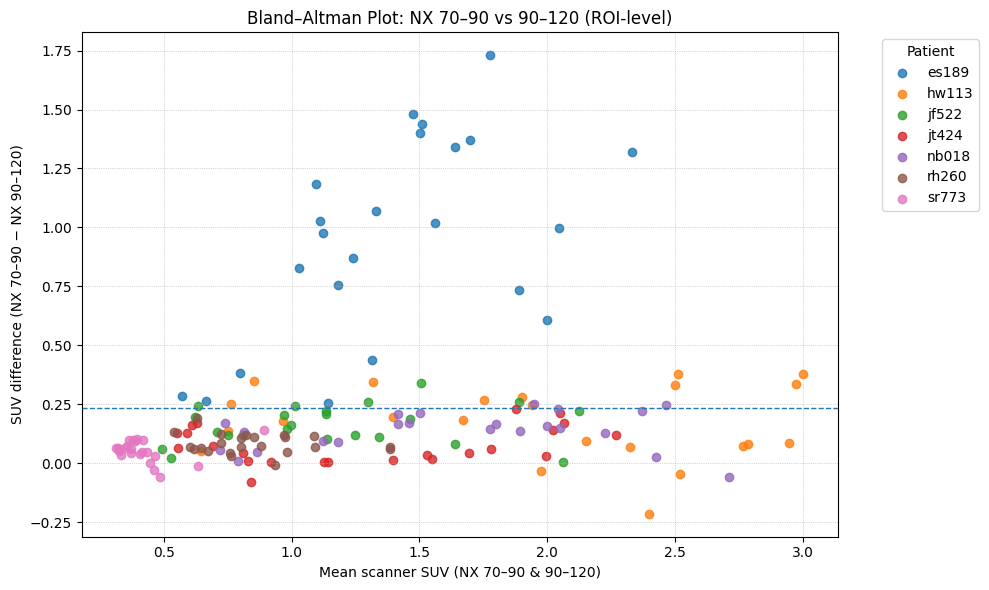

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

for patient, sub in ba_df.groupby("patient"):
    ax.scatter(
        sub["mean_suv"],
        sub["diff_suv"],
        label=patient,
        alpha=0.8
    )

# Optional: show overall mean difference line (remove if you want *only* points)
overall_mean = ba_df["diff_suv"].mean()
ax.axhline(overall_mean, linestyle="--", linewidth=1)

ax.set_title("Bland–Altman Plot: NX 70–90 vs 90–120 (ROI-level)")
ax.set_xlabel("Mean scanner SUV (NX 70–90 & 90–120)")
ax.set_ylabel("SUV difference (NX 70–90 − NX 90–120)")
ax.legend(title="Patient", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, linestyle=":", linewidth=0.5)

plt.tight_layout()
plt.show()